# Displacement Plot

Loads a tracking CSV, plots Δx vs real time, and plots the frequency spectrum.

Edit the settings below, then run all cells.

In [ ]:
# ====== EDIT THIS ======
CSV_PATH      = r"C:\Users\svend\Downloads\strain_tracking_2026-05-23T13-02-04.csv"   # path to your CSV (use r"..." on Windows)
SLOWMO_FACTOR = 4                      # 4 for 120 fps slow-mo on phones; 1 for real-time video

# Y-axis limits for displacement plot — set both to zoom in, leave as None for auto
Y_MIN = None    # e.g. 0.0
Y_MAX = None    # e.g. 0.5

# Frequency axis limits — set to cap the x-axis of the spectrum plot, None for full range
FREQ_MIN = 1.0   # hide frequencies below this value
FREQ_MAX = 20    # e.g. 10.0  (Hz)
# =======================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv(CSV_PATH, comment="#")

dx_cols = [c for c in df.columns if c.startswith("dx_") and c != "dx_px"]
dx_col  = dx_cols[0] if dx_cols else "dx_px"
unit    = dx_col.split("_", 1)[1]

t = df["time_s"].to_numpy() / SLOWMO_FACTOR
x = -df[dx_col].to_numpy()

print(f"Loaded {len(df)} rows  ·  column: {dx_col}  ·  duration: {t[-1]:.3f} s real time")
print(f"Δx range: {x.min():.4f} → {x.max():.4f} {unit}")

Loaded 1538 rows  ·  column: dx_mm  ·  duration: 3.310 s real time
Δx range: -0.0000 → 41.4423 mm


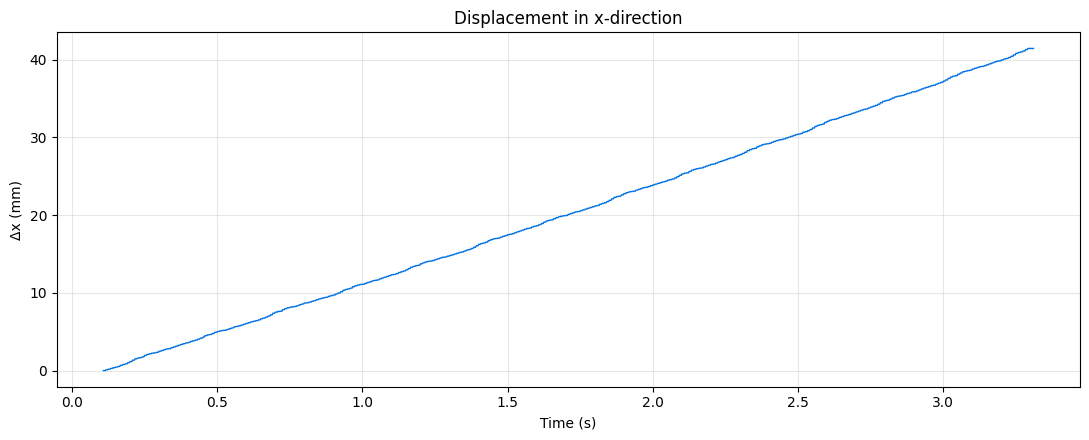

In [8]:
# ---- Displacement plot ----
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t, x, color="#0071e3", linewidth=1.0)
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Δx ({unit})")
ax.set_title("Displacement in x-direction")
ax.grid(True, alpha=0.3)

if Y_MIN is not None or Y_MAX is not None:
    ax.set_ylim(
        Y_MIN if Y_MIN is not None else x.min(),
        Y_MAX if Y_MAX is not None else x.max(),
    )

plt.tight_layout()
plt.show()

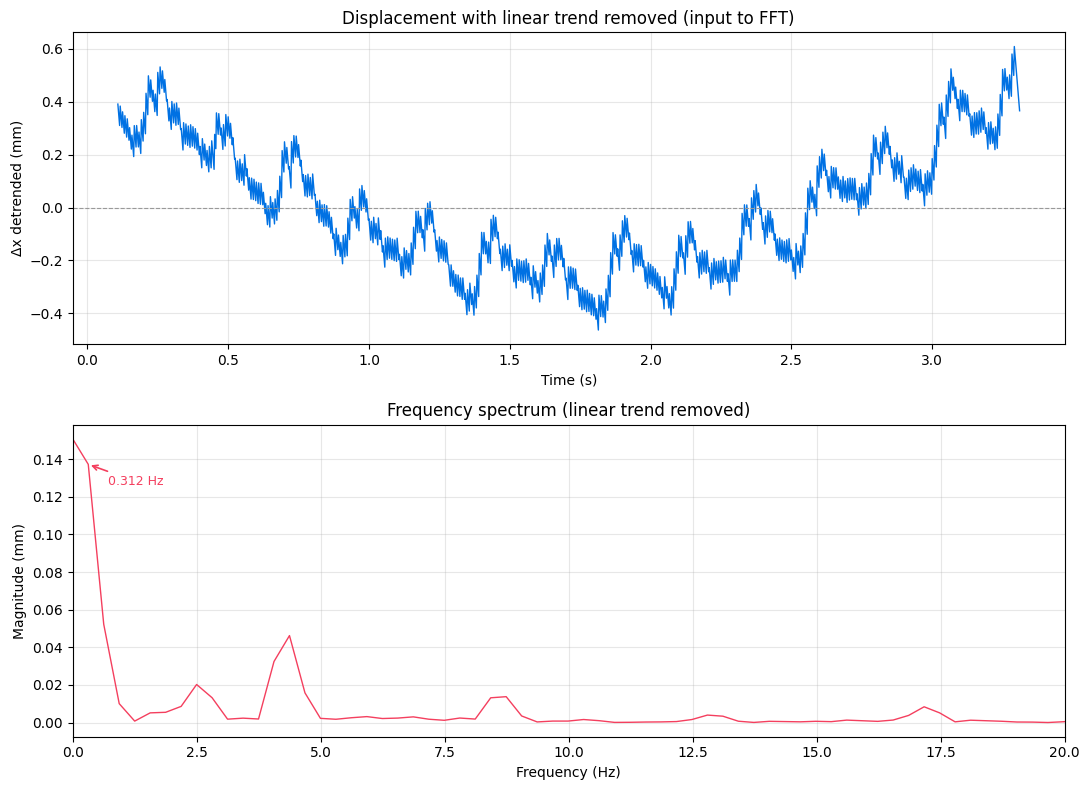

Linear trend:        +12.9502 mm/s
Dominant frequency:  0.3121 Hz  (18.73 RPM  ·  magnitude 0.1372 mm)
Sample rate:         480.02 Hz  (Nyquist limit: 240.01 Hz)


In [ ]:
# ---- Frequency spectrum ----
# Remove the linear trend first — otherwise the slow rise from start to end
# dominates the spectrum and hides the actual oscillations.
# After detrending, apply a Hann window to reduce spectral leakage.
dt   = float(np.median(np.diff(t)))
fs   = 1.0 / dt
n    = len(x)

# Fit and subtract a straight line
coeffs  = np.polyfit(t, x, 1)
trend   = np.polyval(coeffs, t)
x_detr  = x - trend

# Hann window + FFT
window  = np.hanning(n)
fft_mag = np.abs(np.fft.rfft(x_detr * window)) * 2 / n
freqs   = np.fft.rfftfreq(n, d=dt)

# ---- Plot: detrended signal so you can see what went into the FFT ----
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

axes[0].plot(t, x_detr, color="#0071e3", linewidth=1.0)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel(f"Δx detrended ({unit})")
axes[0].set_title("Displacement with linear trend removed (input to FFT)")
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color="#999", linewidth=0.8, linestyle="--")

freq_mask = freqs >= FREQ_MIN
axes[1].plot(freqs[freq_mask], fft_mag[freq_mask], color="#f43f5e", linewidth=1.0)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(f"Magnitude ({unit})")
axes[1].set_title("Frequency spectrum (linear trend removed)")
axes[1].grid(True, alpha=0.3)

xlim_min = FREQ_MIN if FREQ_MIN is not None else 0
xlim_max = FREQ_MAX if FREQ_MAX is not None else None
if xlim_max is None:
    axes[1].set_xlim(xlim_min, freqs[freq_mask][-1])
else:
    axes[1].set_xlim(xlim_min, xlim_max)

start_idx = max(1, np.searchsorted(freqs, FREQ_MIN, side="left"))
peak_idx  = start_idx + np.argmax(fft_mag[start_idx:])
peak_freq = freqs[peak_idx]
peak_mag  = fft_mag[peak_idx]
axes[1].annotate(f"{peak_freq:.3f} Hz",
                 xy=(peak_freq, peak_mag),
                 xytext=(peak_freq + 0.02 * (FREQ_MAX or freqs[-1]), peak_mag * 0.92),
                 fontsize=9, color="#f43f5e",
                 arrowprops=dict(arrowstyle="->", color="#f43f5e", lw=1.2))

plt.tight_layout()
plt.show()

print(f"Sample rate:         {fs:.2f} Hz  (Nyquist limit: {fs/2:.2f} Hz)")

print(f"Linear trend:        {coeffs[0]:+.4f} {unit}/s")print(f"Dominant frequency:  {peak_freq:.4f} Hz  ({peak_freq * 60:.2f} RPM  ·  magnitude {peak_mag:.4f} {unit})")